In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
import sys
sys.path.insert(0, '/Users/bryan.carroll/Library/CloudStorage/GoogleDrive-bryan.carroll@wise.com/My Drive/BryWise/AI')
import wise_colours



In [17]:
# Load the data
full_data = pd.read_csv('2026-06-24.csv', low_memory=False)

# Deduplicate survey responses: keep only the first survey per profile
first_survey = full_data.groupby('PROFILE_ID')['SURVEY_DATE'].transform('min')
full_data = full_data[full_data['SURVEY_DATE'] == first_survey]

# Time to first transfer in days
full_data['time_to_first_transfer'] = (
    pd.to_datetime(full_data['TRANSACTION_DATE']) - pd.to_datetime(full_data['SURVEY_DATE'])
) / pd.Timedelta(days=1)

# Aggregate transaction-level data to per-user summary (one row per profile)
txn_agg = full_data.groupby('PROFILE_ID').agg(
    CES_SCORE=('CES_SCORE', 'first'),
    CES_COMMENT=('CES_COMMENT', 'first'),
    SURVEY_DATE=('SURVEY_DATE', 'first'),
    PLATFORM=('PLATFORM', 'first'),
    VERIFICATION_START_TS=('VERIFICATION_START_TS', 'first'),
    # Support contacts
    HAD_KYC_CONTACT=('HAD_KYC_CONTACT', 'first'),
    KYC_CONTACT_COUNT=('KYC_CONTACT_COUNT', 'first'),
    FIRST_KYC_CONTACT_TS=('FIRST_KYC_CONTACT_TS', 'first'),
    LAST_KYC_CONTACT_TS=('LAST_KYC_CONTACT_TS', 'first'),
    # Transactions
    first_transaction_date=('TRANSACTION_DATE', 'min'),
    first_transaction_gbp=('INVOICE_AMOUNT_GBP', 'first'),
    send_count=('TRANSFER_ID', 'nunique'),
    send_value_gbp=('INVOICE_AMOUNT_GBP', 'sum')
).reset_index()

# Recalculate time to first transfer at profile level
txn_agg['time_to_first_transfer'] = (
    pd.to_datetime(txn_agg['first_transaction_date']) - pd.to_datetime(txn_agg['SURVEY_DATE'])
) / pd.Timedelta(days=1)

# df = users who converted (have at least one transaction post-survey)
df = txn_agg[txn_agg['first_transaction_date'].notna()].copy()
df['SURVEY_MONTH'] = pd.to_datetime(df['SURVEY_DATE']).dt.to_period('M')

# Check shape
print(f"Total profiles: {txn_agg['PROFILE_ID'].nunique():,}")
print(f"Platforms: {txn_agg['PLATFORM'].unique().tolist()}")
print(f"Platform counts (profiles):")
print(txn_agg['PLATFORM'].value_counts())
print(f"\nProfiles with transactions: {df['PROFILE_ID'].nunique():,}")
print(f"\n--- Contacts ---")
print(f"Had KYC contact: {txn_agg['HAD_KYC_CONTACT'].value_counts().to_dict()}")
print(f"KYC contact count (mean, contacted only): {txn_agg[txn_agg['HAD_KYC_CONTACT']==1]['KYC_CONTACT_COUNT'].mean():.2f}")
print(f"\n--- CES by contact status ---")
print(f"Mean CES (contacted):     {txn_agg[txn_agg['HAD_KYC_CONTACT']==1]['CES_SCORE'].mean():.2f}")
print(f"Mean CES (not contacted): {txn_agg[txn_agg['HAD_KYC_CONTACT']==0]['CES_SCORE'].mean():.2f}")

Total profiles: 2,904
Platforms: ['WEB', 'MOBILE_WEB']
Platform counts (profiles):
PLATFORM
WEB           2253
MOBILE_WEB     651
Name: count, dtype: int64

Profiles with transactions: 2,418

--- Contacts ---
Had KYC contact: {0: 1452, 1: 1452}
KYC contact count (mean, contacted only): 1.18

--- CES by contact status ---
Mean CES (contacted):     5.16
Mean CES (not contacted): 5.74


## Support Contact Rate as a measure of User Experience.
We currently track "support contact rate" as a key metric. This is a critical measure of cost and important to measure. 

I want to assess whether or not we can safely use support contact rate as a proxy for user experience. To do this I've utilised the CES score and the follow on transactions/transaction volume. 

This builds on the prior analysis which showed that CES was associated with follow on transfer count and volume - higher CES scores were associated with ~7-8% increase in transaction count and volume. So it follows that if contacting support is also associated with lower CES scores, and similarly reduced transaction volumes, contact rate could be a good proxy of user experience. 

To do this, I created two groups:
- users who started verification, contacted support for a "kyc" reason, and then took the survey
- users who started verification, did not contact support, and then took the survey

Getting these groups right was fairly tricky, and also very important to the outcome. To ensure that this is measuring the right thing, the support contact has to happen AFTER verification start, and BEFORE the survey.

Narrowing down the user group with this strict requirement means that I was not able to do this analysis for personal verification, as the numbers were not there. 

There are also two subsets of this user group - those who were transacting before verification (existing users) and those who were not (new users). The analysis counts the post contact transactions for both groups. 

**Findings & Implications**
- Users who contact suppport DO have lower CES scores. i.e., *contacting support is a worse experience than not having to contact support*
- However, users who contact support have **MUCH higher** follow on transaction rates. This is the opposite of what we'd expect given the lower CES score.
- This is because contacting support is a signal that **confounds intent/need with the experience**.
- As a result, using support contact rate to describe user experience is only partially correct. Importantly, increases or decreases to contact rate COULD indicate a change to user experience, but it could also indicate a mix-shift in who is making it through the experience. 
- A purpose built perception measure - in this case, CES - captures the experience perception regardless of intent. So, if you're launching a change and need to assess the impact on user experience, *it'd be better to ship a specific perception measure and measure that rather than relying solely on contact rate*.

#### This just sounds like mental gymnastics, what's the harm in simply using Contact Rate? You said it's a worse experience, so what's the problem? 

As a hypothetical, imagine we decide we've had enough of support spending and ship a UI that tells people "Don't bother contacting support, we're not going to help you, get lost." The people who weren't going to contact support would continue not to do so, and the people who would have will stop. 
- Contact rate goes down. 
- But that's obviously a worse experience, and those people who we're now churning would have had more engagement over the long run. 

That's obviously a crazy scenario. But, it's not impossible that we ship a UI that **inadvertently** tells people the same thing. Even with everyone full of good intent to make a better user experience, translating intent to perception in product design is not a foolproof process. In this more realistic scenario:
- Contact rate would **also** drop, for the same reasons as the hypothetical scenario. 
- Measuring contact rate alone, we'd have no way to know that the UI was actually a worse experience, and this damage wouldn't show up until months later in the follow-on transactions numbers. 

The perception measure gives the instant, undistorted signal that we got the experience right or wrong. 

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

def fit_count_model(formula, data, label=""):
    """Try NegBin first; fall back to Poisson with robust SEs if NegBin fails."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            m = smf.negativebinomial(formula, data=data).fit(maxiter=1000, disp=False)
            if not m.mle_retvals['converged'] or np.any(np.isnan(m.bse)):
                raise RuntimeError("NegBin did not produce valid estimates")
            return m, 'NegBin'
        except (RuntimeError, np.linalg.LinAlgError, ValueError):
            m = smf.poisson(formula, data=data).fit(maxiter=1000, disp=False, cov_type='HC0')
            return m, 'Poisson (robust SE)'

# --- FOLLOW-ON TRANSFER COUNT (Negative Binomial) ---
df_reg = df.copy()
df_reg['followon_count'] = df_reg['send_count'] - 1
df_reg = df_reg[df_reg['followon_count'] >= 0]

p95 = df_reg['followon_count'].quantile(0.95)
df_reg['followon_count_w'] = df_reg['followon_count'].clip(upper=p95)

model_count, model_type = fit_count_model(
    'followon_count_w ~ CES_SCORE + C(PLATFORM) + HAD_KYC_CONTACT',
    data=df_reg
)

print("=" * 70)
print("NEGATIVE BINOMIAL: Follow-On Transfer COUNT ~ CES + Platform + Contact")
print("=" * 70)
print(f"Model type: {model_type} (n={len(df_reg):,}, followon_count winsorized at p95={p95:.0f})")
print(f"\n{'Parameter':<30} {'Coef':>8} {'Rate Ratio':>12} {'p-value':>10} {'Sig':>4}")
print("-" * 70)
for p_name in ['CES_SCORE', 'HAD_KYC_CONTACT'] + [k for k in model_count.params.index if 'PLATFORM' in k]:
    coef = model_count.params[p_name]
    rr = np.exp(coef)
    pval = model_count.pvalues[p_name]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {p_name:<28} {coef:>8.4f} {rr:>12.3f} {pval:>10.4f} {sig:>4}")

print(f"\n→ Each +1 CES point is associated with {(np.exp(model_count.params['CES_SCORE'])-1)*100:+.1f}% more follow-on transfers")
print(f"→ Having a KYC contact - holding CES constant - is associated with {(np.exp(model_count.params['HAD_KYC_CONTACT'])-1)*100:+.1f}% change in follow-on transfers")

# --- FOLLOW-ON TRANSFER VALUE (Gamma GLM) ---
df_val = df.copy()
df_val['followon_value'] = df_val['send_value_gbp'] - df_val['first_transaction_gbp']
df_val = df_val[df_val['followon_value'] > 0]

p95_val = df_val['followon_value'].quantile(0.95)
df_val['followon_value_w'] = df_val['followon_value'].clip(upper=p95_val)

gamma_model = smf.glm(
    'followon_value_w ~ CES_SCORE + C(PLATFORM) + HAD_KYC_CONTACT',
    data=df_val,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(f"\n{'=' * 70}")
print("GAMMA GLM (log-link): Follow-On Transfer VALUE ~ CES + Platform + Contact")
print("=" * 70)
print(f"n={len(df_val):,}, winsorized at p95=£{p95_val:,.0f}")
print(f"\n{'Parameter':<30} {'Coef':>8} {'Multiplier':>12} {'p-value':>10} {'Sig':>4}")
print("-" * 70)
for p_name in ['CES_SCORE', 'HAD_KYC_CONTACT'] + [k for k in gamma_model.params.index if 'PLATFORM' in k]:
    coef = gamma_model.params[p_name]
    mult = np.exp(coef)
    pval = gamma_model.pvalues[p_name]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {p_name:<28} {coef:>8.4f} {mult:>12.3f} {pval:>10.4f} {sig:>4}")

print(f"\n→ Each +1 CES point is associated with {(np.exp(gamma_model.params['CES_SCORE'])-1)*100:+.1f}% more follow-on transfer value")
print(f"→ Having a KYC contact - holding CES constant - is associated with {(np.exp(gamma_model.params['HAD_KYC_CONTACT'])-1)*100:+.1f}% change in follow-on transfer value")

NEGATIVE BINOMIAL: Follow-On Transfer COUNT ~ CES + Platform + Contact
Model type: NegBin (n=2,334, followon_count winsorized at p95=447)

Parameter                          Coef   Rate Ratio    p-value  Sig
----------------------------------------------------------------------
  CES_SCORE                      0.0722        1.075     0.0000  ***
  HAD_KYC_CONTACT                0.5076        1.661     0.0000  ***
  C(PLATFORM)[T.WEB]             0.1420        1.153     0.0775   ns

→ Each +1 CES point is associated with +7.5% more follow-on transfers
→ Having a KYC contact - holding CES constant - is associated with +66.1% change in follow-on transfers

GAMMA GLM (log-link): Follow-On Transfer VALUE ~ CES + Platform + Contact
n=2,262, winsorized at p95=£1,903,146

Parameter                          Coef   Multiplier    p-value  Sig
----------------------------------------------------------------------
  CES_SCORE                      0.1179        1.125     0.0000  ***
  HAD_KYC_CONTAC

In [19]:
# Interaction test: does the CES → follow-on transfer relationship differ by contact status?
df_int = df.copy()
df_int['followon_count'] = df_int['send_count'] - 1
df_int = df_int[df_int['followon_count'] >= 0]

p95 = df_int['followon_count'].quantile(0.95)
df_int['followon_count_w'] = df_int['followon_count'].clip(upper=p95)

model_interaction, int_model_type = fit_count_model(
    'followon_count_w ~ CES_SCORE * HAD_KYC_CONTACT + C(PLATFORM)',
    data=df_int
)

print("=" * 70)
print("INTERACTION MODEL: CES × KYC Contact → Follow-On Transfers")
print("=" * 70)
print(f"Model type: {int_model_type} (n={len(df_int):,})")
print(f"\n{'Parameter':<35} {'Coef':>8} {'Rate Ratio':>12} {'p-value':>10} {'Sig':>4}")
print("-" * 75)
for p_name in ['Intercept', 'CES_SCORE', 'HAD_KYC_CONTACT', 'CES_SCORE:HAD_KYC_CONTACT'] + [k for k in model_interaction.params.index if 'PLATFORM' in k]:
    if p_name in model_interaction.params.index:
        coef = model_interaction.params[p_name]
        rr = np.exp(coef)
        pval = model_interaction.pvalues[p_name]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"  {p_name:<33} {coef:>8.4f} {rr:>12.3f} {pval:>10.4f} {sig:>4}")

# Interpretation
int_p = model_interaction.pvalues.get('CES_SCORE:HAD_KYC_CONTACT', 1)
ces_coef = model_interaction.params['CES_SCORE']
int_coef = model_interaction.params.get('CES_SCORE:HAD_KYC_CONTACT', 0)

print(f"\n--- Stratified CES effect ---")
print(f"  Not contacted: +{(np.exp(ces_coef)-1)*100:.1f}% per CES point")
print(f"  Contacted:     +{(np.exp(ces_coef + int_coef)-1)*100:.1f}% per CES point")

print(f"\n--- Interpretation ---")
if int_p < 0.05:
    if int_coef > 0:
        print(f"  Interaction is SIGNIFICANT (p={int_p:.4f}): CES has a STRONGER effect for contacted users.")
        print(f"  Users who contacted support and still rated high are especially likely to transact heavily.")
    else:
        print(f"  Interaction is SIGNIFICANT (p={int_p:.4f}): CES has a WEAKER effect for contacted users.")
        print(f"  For contacted users, the experience-to-outcome link is attenuated (intent dominates).")
else:
    print(f"  Interaction is NOT significant (p={int_p:.4f}): the CES slope is similar for both groups.")
    print(f"  Contact status shifts the baseline (intent confound) but doesn't moderate how CES affects outcomes.")

INTERACTION MODEL: CES × KYC Contact → Follow-On Transfers
Model type: NegBin (n=2,334)

Parameter                               Coef   Rate Ratio    p-value  Sig
---------------------------------------------------------------------------
  Intercept                           3.4446       31.330     0.0000  ***
  CES_SCORE                           0.0699        1.072     0.0091   **
  HAD_KYC_CONTACT                     0.4862        1.626     0.0167    *
  CES_SCORE:HAD_KYC_CONTACT           0.0038        1.004     0.9112   ns
  C(PLATFORM)[T.WEB]                  0.1418        1.152     0.0779   ns

--- Stratified CES effect ---
  Not contacted: +7.2% per CES point
  Contacted:     +7.6% per CES point

--- Interpretation ---
  Interaction is NOT significant (p=0.9112): the CES slope is similar for both groups.
  Contact status shifts the baseline (intent confound) but doesn't moderate how CES affects outcomes.


To start, since this is sampled data and a specific subset of the audience, I ran the same model that looks at CES -> follow on transactions. Fortunately, the relationship is almost identical to the prior set, with ~7% follow on transaction per CES point association. 

While this confirms that the CES/worse outcomes association holds true, it shows a substantially different than expected relationship between having a support experience and follow on outcome:
- The hypothesis was that support contact would be a worse experience and therefore worse follow on economic outcomes. 
- This shows the opposite, at an extremely high (~+60%) magnitude.

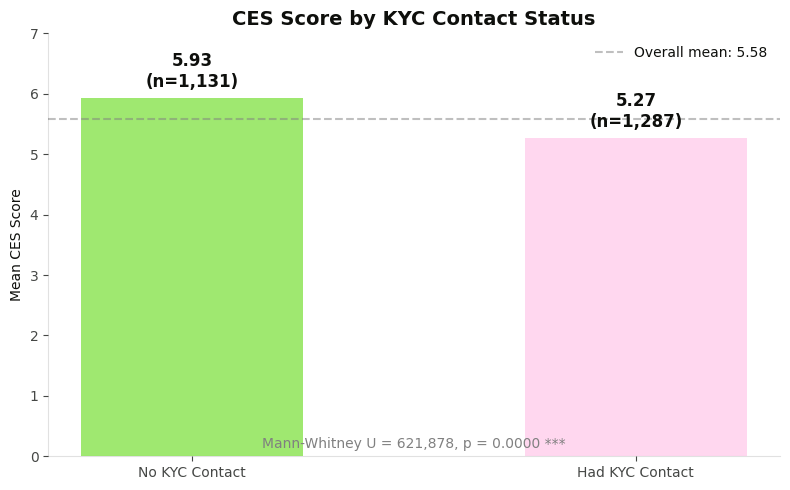


Contacted users report stat sig lower CES (worse experience).
  No contact:  M=5.93, Mdn=7
  Had contact: M=5.27, Mdn=7
  Difference:  0.66 points


In [20]:
# CES Score by Contact Status — mean comparison with significance test
from scipy.stats import mannwhitneyu

contacted = df[df['HAD_KYC_CONTACT'] == 1]['CES_SCORE']
not_contacted = df[df['HAD_KYC_CONTACT'] == 0]['CES_SCORE']

stat, p = mannwhitneyu(contacted, not_contacted, alternative='two-sided')

fig, ax = plt.subplots(figsize=(8, 5))

means = [not_contacted.mean(), contacted.mean()]
labels = ['No KYC Contact', 'Had KYC Contact']
colors = [wise_colours.BRIGHT_GREEN, wise_colours.BRIGHT_PINK]

bars = ax.bar(labels, means, color=colors, width=0.5)

for bar, mean, n in zip(bars, means, [len(not_contacted), len(contacted)]):
    ax.annotate(f"{mean:.2f}\n(n={n:,})", 
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

ax.set_ylabel('Mean CES Score')
ax.set_ylim(0, 7)
ax.set_title('CES Score by KYC Contact Status')
ax.axhline(y=df['CES_SCORE'].mean(), color='grey', linestyle='--', alpha=0.5, label=f"Overall mean: {df['CES_SCORE'].mean():.2f}")
ax.legend()

sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text(0.5, 0.02, f"Mann-Whitney U = {stat:,.0f}, p = {p:.4f} {sig}", 
        transform=ax.transAxes, ha='center', fontsize=10, color='grey')

plt.tight_layout()
plt.show()

print(f"\nContacted users report stat sig lower CES (worse experience).")
print(f"  No contact:  M={not_contacted.mean():.2f}, Mdn={not_contacted.median():.0f}")
print(f"  Had contact: M={contacted.mean():.2f}, Mdn={contacted.median():.0f}")
print(f"  Difference:  {not_contacted.mean() - contacted.mean():.2f} points")

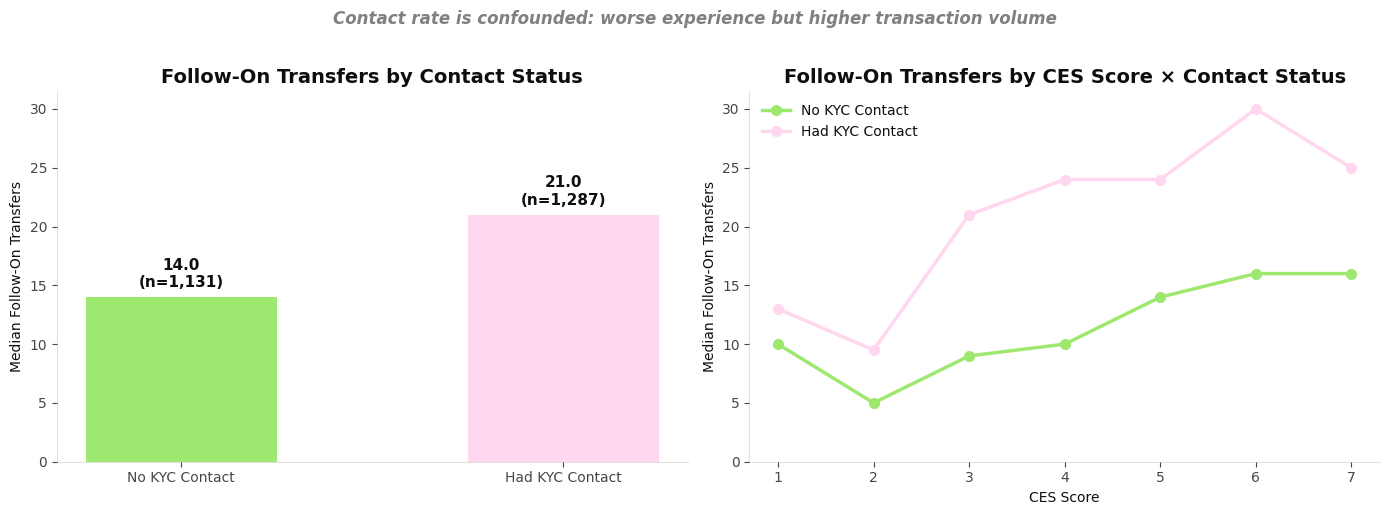

Left: Contacted users make MORE follow-on transfers despite worse CES.
Right: CES still predicts outcomes in both groups, but the contacted baseline is shifted up.
→ Contact captures intent/motivation, not just experience quality.


In [21]:
# The Paradox: contacted users have worse experience BUT more follow-on transfers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: median follow-on transfers by contact status ---
ax = axes[0]
contact_meds = df.groupby('HAD_KYC_CONTACT')['send_count'].median()
labels = ['No KYC Contact', 'Had KYC Contact']
colors = [wise_colours.BRIGHT_GREEN, wise_colours.BRIGHT_PINK]

bars = ax.bar(labels, [contact_meds[0], contact_meds[1]], color=colors, width=0.5)

for bar, val, n in zip(bars, [contact_meds[0], contact_meds[1]], 
                         [len(df[df['HAD_KYC_CONTACT']==0]), len(df[df['HAD_KYC_CONTACT']==1])]):
    ax.annotate(f"{val:.1f}\n(n={n:,})", 
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

ax.set_ylabel('Median Follow-On Transfers')
ax.set_title('Follow-On Transfers by Contact Status')
ax.set_ylim(0, contact_meds.max() * 1.5)

# --- Right panel: follow-on transfers by CES, stratified by contact status ---
ax = axes[1]

ces_contact = df.groupby(['CES_SCORE', 'HAD_KYC_CONTACT'])['send_count'].median().reset_index()

for contact_val, color, label in [(0, wise_colours.BRIGHT_GREEN, 'No KYC Contact'), 
                                   (1, wise_colours.BRIGHT_PINK, 'Had KYC Contact')]:
    subset = ces_contact[ces_contact['HAD_KYC_CONTACT'] == contact_val]
    ax.plot(subset['CES_SCORE'], subset['send_count'], 
            color=color, marker='o', linewidth=2.5, markersize=7, label=label)

ax.set_xlabel('CES Score')
ax.set_ylabel('Median Follow-On Transfers')
ax.set_title('Follow-On Transfers by CES Score × Contact Status')
ax.set_xticks(range(1, 8))
ax.set_ylim(0, contact_meds.max() * 1.5)
ax.legend()

fig.suptitle('Contact rate is confounded: worse experience but higher transaction volume', 
             fontsize=12, y=1.02, style='italic', color='grey')
plt.tight_layout()
plt.show()

print("Left: Contacted users make MORE follow-on transfers despite worse CES.")
print("Right: CES still predicts outcomes in both groups, but the contacted baseline is shifted up.")
print("→ Contact captures intent/motivation, not just experience quality.")

What seems to be happening here is that while the CES relationship is the same, hthe baseline value between contacting support and not contacting support groups are shifted, with those who contact support having a much higher baseline. This is evidence of the intent/need confounding the model.

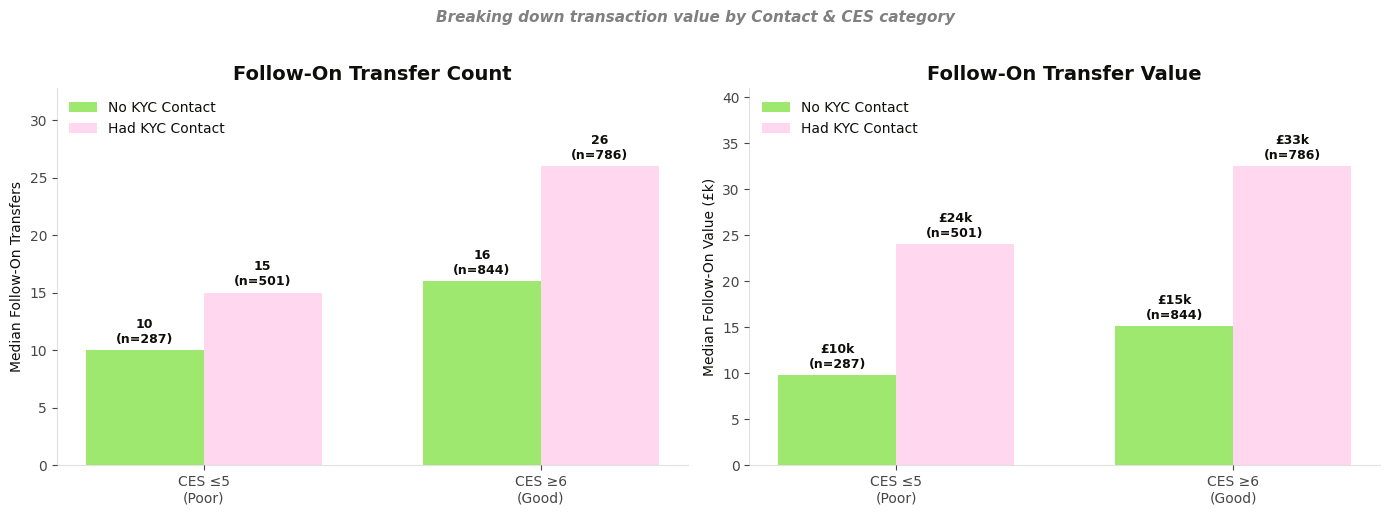

In [22]:
# 2×2 framing, but on matched/controlled data

m_df = df.copy()
m_df['ces_cat'] = m_df['CES_SCORE'].apply(lambda x: "CES ≥6\n(Good)" if x >= 6 else "CES ≤5\n(Poor)")

summary = m_df.groupby(['HAD_KYC_CONTACT', 'ces_cat']).agg(
    mean_followon_count=('send_count', 'mean'),
    mean_followon_value=('send_value_gbp', 'mean'),
    med_followon_count=('send_count', 'median'),
    med_followon_value=('send_value_gbp', 'median'),
    count=('PROFILE_ID', 'count')
).reset_index()

summary['contact_label'] = summary['HAD_KYC_CONTACT'].map({0: 'No KYC Contact', 1: 'Had KYC Contact'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Mean follow-on transfer COUNT ---
ax = axes[0]
x = np.arange(2)
width = 0.35

no_contact = summary[summary['HAD_KYC_CONTACT'] == 0].sort_values('ces_cat')
has_contact = summary[summary['HAD_KYC_CONTACT'] == 1].sort_values('ces_cat')

bars1 = ax.bar(x - width/2, no_contact['med_followon_count'].values, width,
               color=wise_colours.BRIGHT_GREEN, label='No KYC Contact')
bars2 = ax.bar(x + width/2, has_contact['med_followon_count'].values, width,
               color=wise_colours.BRIGHT_PINK, label='Had KYC Contact')

ax.set_xticks(x)
ax.set_xticklabels(no_contact['ces_cat'].values)
ax.set_ylabel('Median Follow-On Transfers')
ax.set_title('Follow-On Transfer Count')
ax.legend()

for bars, data in [(bars1, no_contact), (bars2, has_contact)]:
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.annotate(f"{row['med_followon_count']:.0f}\n(n={row['count']:,})",
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

# --- Right: Mean follow-on transfer VALUE ---
ax = axes[1]

bars1 = ax.bar(x - width/2, no_contact['med_followon_value'].values / 1000, width,
               color=wise_colours.BRIGHT_GREEN, label='No KYC Contact')
bars2 = ax.bar(x + width/2, has_contact['med_followon_value'].values / 1000, width,
               color=wise_colours.BRIGHT_PINK, label='Had KYC Contact')

ax.set_xticks(x)
ax.set_xticklabels(no_contact['ces_cat'].values)
ax.set_ylabel('Median Follow-On Value (£k)')
ax.set_title('Follow-On Transfer Value')
ax.legend()

for bars, data in [(bars1, no_contact), (bars2, has_contact)]:
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.annotate(f"£{row['med_followon_value']/1000:.0f}k\n(n={row['count']:,})",
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

fig.suptitle("Breaking down transaction value by Contact & CES category",
             fontsize=11, y=1.02, style='italic', color='grey')
plt.tight_layout()
plt.show()

This relationship can be seen more clearly in this visualisation:
- while lower/higher CES scores have lower/higher median transfer counts and values, the audience who contacts support tends to be higher in number and value across the board. 

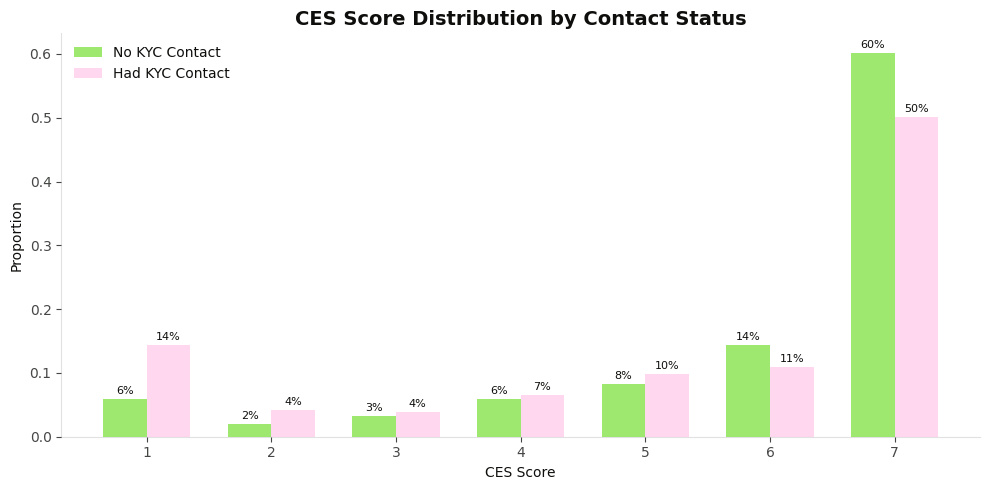

In [23]:
# CES distribution by contact status
fig, ax = plt.subplots(figsize=(10, 5))

scores = range(1, 8)
width = 0.35

contacted_dist = df[df['HAD_KYC_CONTACT'] == 1]['CES_SCORE'].value_counts(normalize=True).reindex(scores, fill_value=0)
not_contacted_dist = df[df['HAD_KYC_CONTACT'] == 0]['CES_SCORE'].value_counts(normalize=True).reindex(scores, fill_value=0)

x = np.arange(len(scores))
bars1 = ax.bar(x - width/2, not_contacted_dist.values, width, color=wise_colours.BRIGHT_GREEN, label='No KYC Contact')
bars2 = ax.bar(x + width/2, contacted_dist.values, width, color=wise_colours.BRIGHT_PINK, label='Had KYC Contact')

ax.set_xlabel('CES Score')
ax.set_ylabel('Proportion')
ax.set_title('CES Score Distribution by Contact Status')
ax.set_xticks(x)
ax.set_xticklabels(scores)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        if bar.get_height() > 0.01:
            ax.annotate(f"{bar.get_height():.0%}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

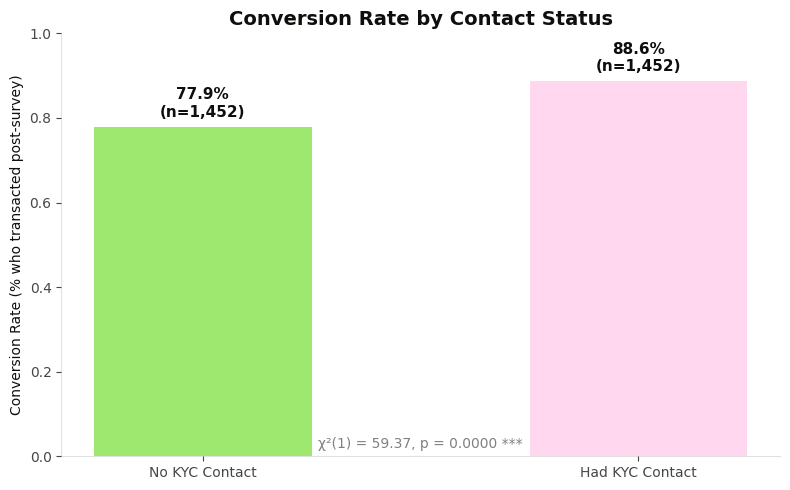


Conversion rate difference: +10.7%pp
Contacted users convert at a higher rate — further evidence of intent/motivation confound.


In [24]:
# Conversion rate by contact status (did the user transact at all post-survey?)
txn_agg['converted'] = txn_agg['first_transaction_date'].notna().astype(int)

conv_by_contact = txn_agg.groupby('HAD_KYC_CONTACT')['converted'].agg(['mean', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

labels = ['No KYC Contact', 'Had KYC Contact']
colors = [wise_colours.BRIGHT_GREEN, wise_colours.BRIGHT_PINK]
rates = conv_by_contact['mean'].values
counts = conv_by_contact['count'].values

bars = ax.bar(labels, rates, color=colors, width=0.5)

for bar, rate, n in zip(bars, rates, counts):
    ax.annotate(f"{rate:.1%}\n(n={n:,})", 
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

ax.set_ylabel('Conversion Rate (% who transacted post-survey)')
ax.set_title('Conversion Rate by Contact Status')
ax.set_ylim(0, 1)

# Chi-square test
ct = pd.crosstab(txn_agg['HAD_KYC_CONTACT'], txn_agg['converted'])
chi2, p, dof, _ = chi2_contingency(ct)
sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text(0.5, 0.02, f"χ²({dof}) = {chi2:.2f}, p = {p:.4f} {sig}", 
        transform=ax.transAxes, ha='center', fontsize=10, color='grey')

plt.tight_layout()
plt.show()

print(f"\nConversion rate difference: {rates[1]-rates[0]:+.1%}pp")
print("Contacted users convert at a higher rate — further evidence of intent/motivation confound.")

In [25]:
# --- CONVERSION model + fit metrics for a binary outcome ----------------------
# The chart above shows the RAW conversion gap; this models it with intent controls
# and reports the right fit measures for a 0/1 outcome (there is no ordinary R^2):
#   * McFadden pseudo-R^2 (.prsquared): log-likelihood gain over an intercept-only
#     model. NOT the OLS scale -- 0.2-0.4 already counts as 'excellent'.
#   * AUC (area under ROC): prob. the model ranks a converter above a non-converter.
#     0.5 = chance, 0.7-0.8 = decent, >0.8 = strong.
from sklearn.metrics import roc_auc_score

conv_df = txn_agg.copy()
conv_df['converted'] = conv_df['first_transaction_date'].notna().astype(int)
# Intent controls are added to txn_agg in a later cell; derive them here from
# full_data so this cell is self-sufficient regardless of run order.
conv_df['IS_EXISTING_USER'] = conv_df['PROFILE_ID'].map(
    full_data.groupby('PROFILE_ID')['IS_EXISTING_USER'].first()).fillna(0).astype(int)
conv_df['PRE_VERIF_TXN_COUNT'] = conv_df['PROFILE_ID'].map(
    full_data.groupby('PROFILE_ID')['PRE_VERIF_TXN_COUNT'].first()).fillna(0).astype(int)

rhs_conv = 'HAD_KYC_CONTACT + IS_EXISTING_USER + PRE_VERIF_TXN_COUNT + C(PLATFORM)'
logit_conv = smf.logit(f'converted ~ {rhs_conv}', data=conv_df).fit(disp=False)

conv_fx = (pd.DataFrame({'odds_ratio': np.exp(logit_conv.params),
                         'pct_odds_change': (np.exp(logit_conv.params) - 1) * 100,
                         'p': logit_conv.pvalues})
             .drop(index='Intercept'))
print(f"=== CONVERSION (logistic, n={int(logit_conv.nobs):,}) — did they transact at all? ===")
display(conv_fx.sort_values('pct_odds_change').round(3))

auc = roc_auc_score(conv_df['converted'], logit_conv.predict())
print(f"\nFit: McFadden pseudo-R^2 = {logit_conv.prsquared:.3f}  |  AUC = {auc:.3f}")
print("INTERPRET: AUC ~0.67 = modest-but-real discrimination -- contact + intent controls")
print("rank converters above non-converters better than chance, but conversion is far from")
print("fully explained by them (overall conversion is high ~83%, leaving little to predict).")
print("McFadden ~0.06 is consistent (its scale: ~0.2-0.4 = 'excellent', so weak-moderate).")
print("Contact's POSITIVE conversion odds echo the volume finding: it flags intent, not a")
print("worse outcome -- the same confound that makes contact rate a poor experience proxy.")

=== CONVERSION (logistic, n=2,904) — did they transact at all? ===


,odds_ratio,pct_odds_change,p
PRE_VERIF_TXN_COUNT,0.983,-1.743,0.386
C(PLATFORM)[T.WEB],1.592,59.213,0.000
HAD_KYC_CONTACT,2.312,131.238,0.000
IS_EXISTING_USER,2.669,166.885,0.000



Fit: McFadden pseudo-R^2 = 0.056  |  AUC = 0.671
INTERPRET: AUC ~0.67 = modest-but-real discrimination -- contact + intent controls
rank converters above non-converters better than chance, but conversion is far from
fully explained by them (overall conversion is high ~83%, leaving little to predict).
McFadden ~0.06 is consistent (its scale: ~0.2-0.4 = 'excellent', so weak-moderate).
Contact's POSITIVE conversion odds echo the volume finding: it flags intent, not a
worse outcome -- the same confound that makes contact rate a poor experience proxy.


Looking at the conversion rate, there is further evidence of a confound. While we might expect people who have a support contact to fail verification at a higher rate, for this audience we see the opposite, with a substantially higher rate of conversion for those who have a support contact. 

This is further evidence that there is an intent/need confound at play. 

Profiles with ≥2 transfers: 2,263
  Contacted:     1,194
  Not contacted: 1,069


/var/folders/1h/w4xhw7bx50xfvy_jpdv3p41h0000gp/T/ipykernel_88031/4049622780.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_contact, labels=['No KYC Contact', 'Had KYC Contact'],


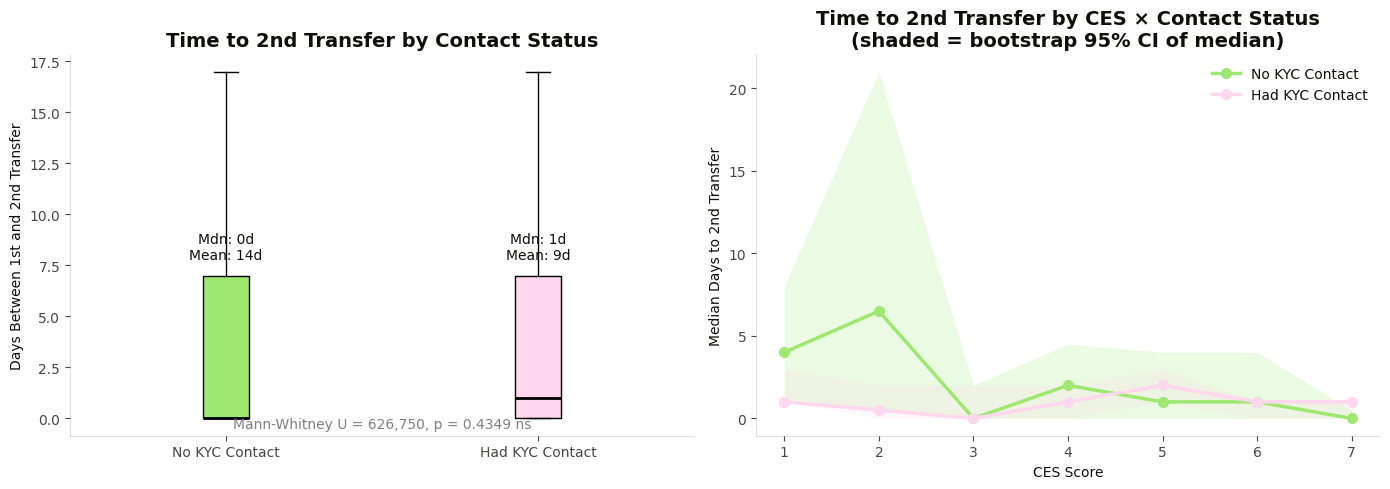


If contacted users return SLOWER, the bad experience creates hesitancy
even though intent eventually brings them back (volume confound).
If similar or faster, intent dominates completely — no hesitancy signal.


In [26]:
# Time to 2nd transfer by contact status
# Need to go back to the transaction-level data to get 1st and 2nd transfer dates per profile

txn_level = full_data[full_data['TRANSACTION_DATE'].notna()].copy()
txn_level['TRANSACTION_DATE'] = pd.to_datetime(txn_level['TRANSACTION_DATE'])
txn_level['SURVEY_DATE_dt'] = pd.to_datetime(txn_level['SURVEY_DATE'])

# Rank transactions per profile by date
txn_level = txn_level.sort_values(['PROFILE_ID', 'TRANSACTION_DATE'])
txn_level['txn_rank'] = txn_level.groupby('PROFILE_ID').cumcount() + 1

# Get 1st and 2nd transfer dates
first_txn = txn_level[txn_level['txn_rank'] == 1][['PROFILE_ID', 'TRANSACTION_DATE']].rename(columns={'TRANSACTION_DATE': 'first_txn_date'})
second_txn = txn_level[txn_level['txn_rank'] == 2][['PROFILE_ID', 'TRANSACTION_DATE']].rename(columns={'TRANSACTION_DATE': 'second_txn_date'})

repeat_df = first_txn.merge(second_txn, on='PROFILE_ID', how='inner')
repeat_df['days_to_2nd'] = (repeat_df['second_txn_date'] - repeat_df['first_txn_date']) / pd.Timedelta(days=1)

# Merge back contact status and CES
repeat_df = repeat_df.merge(
    df[['PROFILE_ID', 'HAD_KYC_CONTACT', 'CES_SCORE']],
    on='PROFILE_ID', how='inner'
)

print(f"Profiles with ≥2 transfers: {len(repeat_df):,}")
print(f"  Contacted:     {(repeat_df['HAD_KYC_CONTACT']==1).sum():,}")
print(f"  Not contacted: {(repeat_df['HAD_KYC_CONTACT']==0).sum():,}")

# --- Plot: time to 2nd transfer by contact status ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplot by contact status
ax = axes[0]
data_contact = [repeat_df[repeat_df['HAD_KYC_CONTACT']==0]['days_to_2nd'],
                repeat_df[repeat_df['HAD_KYC_CONTACT']==1]['days_to_2nd']]

bp = ax.boxplot(data_contact, labels=['No KYC Contact', 'Had KYC Contact'], 
                showfliers=False, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor(wise_colours.BRIGHT_GREEN)
bp['boxes'][1].set_facecolor(wise_colours.BRIGHT_PINK)

for i, d in enumerate(data_contact):
    ax.annotate(f"Mdn: {d.median():.0f}d\nMean: {d.mean():.0f}d", 
                (i+1, d.quantile(0.75)), ha='center', va='bottom', fontsize=10,
                xytext=(0, 10), textcoords='offset points')

ax.set_ylabel('Days Between 1st and 2nd Transfer')
ax.set_title('Time to 2nd Transfer by Contact Status')

stat, p = mannwhitneyu(data_contact[0], data_contact[1], alternative='two-sided')
sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text(0.5, 0.02, f"Mann-Whitney U = {stat:,.0f}, p = {p:.4f} {sig}", 
        transform=ax.transAxes, ha='center', fontsize=10, color='grey')

# Right: time to 2nd transfer by CES, stratified by contact status
# Median line with a bootstrapped 95% CI band (shaded) per CES x contact cell.
ax = axes[1]

def median_ci(values, n_boot=2000, ci=95):
    """Bootstrap CI for the median. Returns (median, lo, hi)."""
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if len(v) == 0:
        return np.nan, np.nan, np.nan
    if len(v) == 1:
        return v[0], v[0], v[0]
    rng = np.random.default_rng(42)
    boots = np.median(rng.choice(v, size=(n_boot, len(v)), replace=True), axis=1)
    lo, hi = np.percentile(boots, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return np.median(v), lo, hi

for contact_val, color, label in [(0, wise_colours.BRIGHT_GREEN, 'No KYC Contact'), 
                                   (1, wise_colours.BRIGHT_PINK, 'Had KYC Contact')]:
    grp = repeat_df[repeat_df['HAD_KYC_CONTACT'] == contact_val]
    rows = []
    for ces in sorted(grp['CES_SCORE'].dropna().unique()):
        med, lo, hi = median_ci(grp[grp['CES_SCORE'] == ces]['days_to_2nd'])
        rows.append((ces, med, lo, hi))
    stats = pd.DataFrame(rows, columns=['CES_SCORE', 'median', 'lo', 'hi'])
    ax.plot(stats['CES_SCORE'], stats['median'], 
            color=color, marker='o', linewidth=2.5, markersize=7, label=label)
    ax.fill_between(stats['CES_SCORE'], stats['lo'], stats['hi'], 
                    color=color, alpha=0.2, linewidth=0)

ax.set_xlabel('CES Score')
ax.set_ylabel('Median Days to 2nd Transfer')
ax.set_title('Time to 2nd Transfer by CES × Contact Status\n(shaded = bootstrap 95% CI of median)')
ax.set_xticks(range(1, 8))
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nIf contacted users return SLOWER, the bad experience creates hesitancy")
print(f"even though intent eventually brings them back (volume confound).")
print(f"If similar or faster, intent dominates completely — no hesitancy signal.")

This shows that having a support contact does create some engagement hesitancy - the users that do need support have a slightly greater time to a second post-contact transfer than those who do not. CES also predicts this, to a greater extent, as the median days to a second transfer are higher at lower CES scores within groups. 

## Testing whether user tenure (new vs existing) drives the effect
Recall from the outset that there are two sub-groups within this populations - those that had prior transfers and had to go through verification again, and those who were starting fresh. 

It's reasonable to assume that the existing users are skewing these results, as they are more embedded in their account and thus would have a higher intent to complete even when faced with a support experience. 

**What the data shows (matched cohort, n≈2,900):** tenure matters, but *not* in the way the hypothesis predicted.

- **Tenure is a real main effect** — existing users make meaningfully more follow-on transfers than new users, holding CES, platform and contact constant. 

- **But it does not moderate the contact effect** — the contact × tenure interaction is *not* significant, and the contact association is actually at least as strong for **new** users as for existing ones. Contact's positive link to volume holds in the same direction for both groups.

In other words: existing users have more post-contact transactions, but removing this cohort from the group wouldn't change the overall finding; that change in baseline doesn't impact the outcome that contact rate is confounded by intent/need.


In [27]:
# --- Add new/existing user flag and rebuild the per-profile frame ---
# IS_EXISTING_USER = 1 if the profile transacted BEFORE verification started.
# (Pulled from the SQL; if loading an older CSV that lacks it, re-run the query.)
if 'IS_EXISTING_USER' not in full_data.columns:
    raise KeyError(
        "IS_EXISTING_USER not in CSV. Re-run business_contacts_ces_transactions.sql "
        "and export a fresh CSV — the column was added to classify new vs existing users."
    )

# One value per profile (it is profile-level, so 'first' is safe)
existing_flag = full_data.groupby('PROFILE_ID')['IS_EXISTING_USER'].first()
pre_cnt = (full_data.groupby('PROFILE_ID')['PRE_VERIF_TXN_COUNT'].first()
           if 'PRE_VERIF_TXN_COUNT' in full_data.columns else None)

for frame in (txn_agg, df):
    frame['IS_EXISTING_USER'] = frame['PROFILE_ID'].map(existing_flag).fillna(0).astype(int)
    if pre_cnt is not None:
        frame['PRE_VERIF_TXN_COUNT'] = frame['PROFILE_ID'].map(pre_cnt).fillna(0).astype(int)

df['USER_TYPE'] = df['IS_EXISTING_USER'].map({0: 'New', 1: 'Existing'})

# --- Prevalence + how the headline metrics split by tenure ---
print("Profile counts by tenure:")
print(txn_agg['IS_EXISTING_USER'].map({0:'New',1:'Existing'}).value_counts(), "\n")

xtab = (df.assign(contact=df['HAD_KYC_CONTACT'].map({0:'No contact',1:'Contacted'}))
          .groupby(['USER_TYPE','contact'])
          .agg(n=('PROFILE_ID','nunique'),
               mean_ces=('CES_SCORE','mean'),
               median_followon=('send_count','median'),
               mean_followon=('send_count','mean'))
          .round(2))


Profile counts by tenure:
IS_EXISTING_USER
New         1896
Existing    1008
Name: count, dtype: int64 



In [28]:
# --- Does tenure (new vs existing) drive the contact effect? ---
# Add IS_EXISTING_USER as a main effect, then test its interaction with contact.
df_t = df.copy()
df_t['followon_count'] = df_t['send_count'] - 1
df_t = df_t[df_t['followon_count'] >= 0]
p95 = df_t['followon_count'].quantile(0.95)
df_t['followon_count_w'] = df_t['followon_count'].clip(upper=p95)

def report(model, params, title, n):
    print("=" * 78)
    print(title)
    print("=" * 78)
    print(f"n={n:,}")
    print(f"\n{'Parameter':<38} {'Coef':>8} {'Rate Ratio':>11} {'p-value':>10} {'Sig':>4}")
    print("-" * 78)
    for p in params:
        if p in model.params.index:
            coef = model.params[p]; pval = model.pvalues[p]
            sig = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'
            print(f"  {p:<36} {coef:>8.4f} {np.exp(coef):>11.3f} {pval:>10.4f} {sig:>4}")

# Baseline contact effect WITHOUT tenure (refit here so the comparison is self-contained)
mBase, _ = fit_count_model(
    'followon_count_w ~ CES_SCORE + C(PLATFORM) + HAD_KYC_CONTACT',
    data=df_t)
contact_baseline = (np.exp(mBase.params['HAD_KYC_CONTACT']) - 1) * 100

# Model A: tenure as a main effect alongside contact
mA, tA = fit_count_model(
    'followon_count_w ~ CES_SCORE + C(PLATFORM) + HAD_KYC_CONTACT + IS_EXISTING_USER',
    data=df_t)
report(mA, ['CES_SCORE','HAD_KYC_CONTACT','IS_EXISTING_USER','C(PLATFORM)[T.WEB]'],
       f"MODEL A ({tA}): +tenure main effect", len(df_t))
print(f"\n→ Existing users make {(np.exp(mA.params['IS_EXISTING_USER'])-1)*100:+.1f}% more follow-on transfers than new users (CES, platform, contact held constant)")
print(f"→ With tenure controlled, the contact coefficient is {(np.exp(mA.params['HAD_KYC_CONTACT'])-1)*100:+.1f}% "
      f"(was {contact_baseline:+.1f}% before controlling for tenure)")

# Model B: does contact bite differently for new vs existing users?
mB, tB = fit_count_model(
    'followon_count_w ~ CES_SCORE + C(PLATFORM) + HAD_KYC_CONTACT * IS_EXISTING_USER',
    data=df_t)
report(mB, ['CES_SCORE','HAD_KYC_CONTACT','IS_EXISTING_USER',
            'HAD_KYC_CONTACT:IS_EXISTING_USER','C(PLATFORM)[T.WEB]'],
       f"MODEL B ({tB}): contact x tenure interaction", len(df_t))

c   = mB.params['HAD_KYC_CONTACT']
ix  = mB.params.get('HAD_KYC_CONTACT:IS_EXISTING_USER', 0)
ixp = mB.pvalues.get('HAD_KYC_CONTACT:IS_EXISTING_USER', 1)
new_eff = (np.exp(c)-1)*100
exist_eff = (np.exp(c+ix)-1)*100
print(f"\n--- Contact effect on follow-on transfers, by tenure ---")
print(f"  New users:      {new_eff:+.1f}%")
print(f"  Existing users: {exist_eff:+.1f}%")
if ixp < 0.05:
    stronger = 'existing' if exist_eff > new_eff else 'new'
    print(f"\n→ Interaction SIGNIFICANT (p={ixp:.4f}): contact's association with follow-on volume")
    print(f"  is stronger for {stronger} users.")
else:
    print(f"\n→ Interaction NOT significant (p={ixp:.4f}): no evidence that contact affects")
    print(f"  new vs existing users differently. The contact association ({new_eff:+.0f}% / {exist_eff:+.0f}%)")
    print(f"  holds in the same direction for both tenures, and tenure enters only as a")
    print(f"  main effect (existing users transact more regardless of contact).")


MODEL A (NegBin): +tenure main effect
n=2,334

Parameter                                  Coef  Rate Ratio    p-value  Sig
------------------------------------------------------------------------------
  CES_SCORE                              0.0708       1.073     0.0000  ***
  HAD_KYC_CONTACT                        0.5255       1.691     0.0000  ***
  IS_EXISTING_USER                       0.2020       1.224     0.0028   **
  C(PLATFORM)[T.WEB]                     0.1375       1.147     0.0870   ns

→ Existing users make +22.4% more follow-on transfers than new users (CES, platform, contact held constant)
→ With tenure controlled, the contact coefficient is +69.1% (was +66.1% before controlling for tenure)
MODEL B (NegBin): contact x tenure interaction
n=2,334

Parameter                                  Coef  Rate Ratio    p-value  Sig
------------------------------------------------------------------------------
  CES_SCORE                              0.0714       1.074     0.0000 

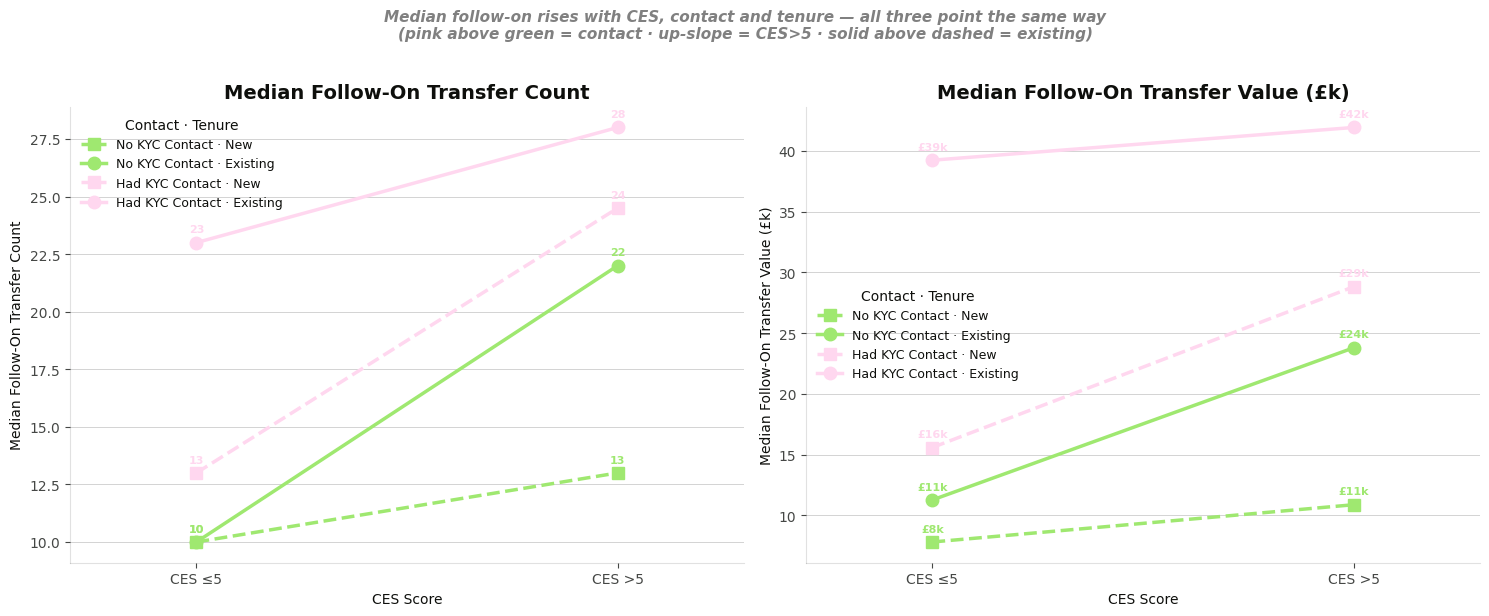

In [31]:
# --- Grouped slope lines: median follow-on across CES, by contact × tenure ---
# X-axis = CES category (≤5 → >5). Colour = contact (green=no, pink=had — consistent
# with the rest of the notebook). Linestyle = tenure (solid=Existing, dashed=New).
# Reads all three "always higher" effects:
#   • pink above green        → contact higher
#   • slope up left→right     → CES higher
#   • solid above dashed      → existing higher
df_h = df.copy()
df_h['ces_cat'] = np.where(df_h['CES_SCORE'] >= 6, 'CES >5', 'CES ≤5')
ces_order = ['CES ≤5', 'CES >5']
ces_x = [0, 1]

# contact -> colour, tenure -> linestyle + marker
combos = [
    (0, 'New',      wise_colours.BRIGHT_GREEN, '--', 's'),
    (0, 'Existing', wise_colours.BRIGHT_GREEN, '-',  'o'),
    (1, 'New',      wise_colours.BRIGHT_PINK,  '--', 's'),
    (1, 'Existing', wise_colours.BRIGHT_PINK,  '-',  'o'),
]
tenure_df = {'New': df_h[df_h['IS_EXISTING_USER'] == 0],
             'Existing': df_h[df_h['IS_EXISTING_USER'] == 1]}
contact_label = {0: 'No KYC Contact', 1: 'Had KYC Contact'}

def med_n(tdf, ces, contact_val, col):
    sub = tdf[(tdf['ces_cat'] == ces) & (tdf['HAD_KYC_CONTACT'] == contact_val)]
    return (sub[col].median() if len(sub) else np.nan), sub['PROFILE_ID'].nunique()

specs = [
    ('send_count',     'Median Follow-On Transfer Count', 1.0, lambda v: f"{v:.0f}"),
    ('send_value_gbp', 'Median Follow-On Transfer Value (£k)', 1e3, lambda v: f"£{v/1e3:.0f}k"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (col, title, scale, fmt) in zip(axes, specs):
    for contact_val, tlabel, color, ls, mk in combos:
        tdf = tenure_df[tlabel]
        ys = []
        for ces in ces_order:
            v, _ = med_n(tdf, ces, contact_val, col)
            ys.append(v / scale if not np.isnan(v) else np.nan)
        ax.plot(ces_x, ys, color=color, linestyle=ls, marker=mk,
                linewidth=2.5, markersize=9,
                label=f"{contact_label[contact_val]} · {tlabel}")
        for xi, yv in zip(ces_x, ys):
            if not np.isnan(yv):
                ax.annotate(fmt(yv*scale), (xi, yv), ha='center', va='bottom',
                            fontsize=8, fontweight='bold', color=color,
                            xytext=(0, 6), textcoords='offset points')
    ax.set_xticks(ces_x)
    ax.set_xticklabels(ces_order)
    ax.set_xlim(-0.3, 1.3)
    ax.set_xlabel('CES Score')
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(title='Contact · Tenure', fontsize=9)

fig.suptitle("Median follow-on rises with CES, contact and tenure — all three point the same way\n"
             "(pink above green = contact · up-slope = CES>5 · solid above dashed = existing)",
             fontsize=11, y=1.02, style='italic', color='grey')
plt.tight_layout()
plt.show()


## Understanding CES's ability to measure the experience impact of a Support Contact

As shown above, CES is lower, all things equal, for those who have a Support Contact experience compared to those who do not. Comparing the models, this becomes clear; the effect of support contact is attitudinal, whereas the downstream financial impact appears driven by the intent confound - which is why controlling for CES increases the contact-volume association rather than shrinking it.

This data shows that the CES measure is effective at detecting this kind of experience impact. I.e., the latent trait that CES is designed to measure, and the impact of having a support contact experience are aligned. Compare this to evidence-related friction, which didn't have a similar effect, and you can start to see the lines within which CES is most useful.

However, like the evidence analysis, this data shows that there are many other factors that shape how people perceive the experience (low R^2).

In [29]:
# --- CES as MEDIATOR: does the contact effect run THROUGH perceived friction? ---
# Replicating the mediation check from the Evidence Friction analysis. The models above
# keep CES_SCORE as a predictor -> that gives contact's effect NET of CES (its DIRECT
# effect). To see how much of contact's effect on follow-on volume runs THROUGH CES,
# also fit WITHOUT CES (the TOTAL effect) and compare:
#     total (no CES) - direct (with CES) = the portion mediated by CES
# Plus the LINK-1 model, CES ~ contact, to check whether contact moves perception at all.
# Intent controls included throughout: IS_EXISTING_USER + PRE_VERIF_TXN_COUNT.
df_med = df.copy()
df_med['followon_count'] = df_med['send_count'] - 1
df_med = df_med[df_med['followon_count'] >= 0]
df_med['followon_count_w'] = df_med['followon_count'].clip(upper=df_med['followon_count'].quantile(0.95))

ctrls = 'C(PLATFORM) + IS_EXISTING_USER + PRE_VERIF_TXN_COUNT'
m_direct, _ = fit_count_model(f'followon_count_w ~ CES_SCORE + HAD_KYC_CONTACT + {ctrls}', data=df_med)
m_total,  _ = fit_count_model(f'followon_count_w ~ HAD_KYC_CONTACT + {ctrls}', data=df_med)

# Link 1: does contact move CES? (OLS; CES ordinal 1-7 -> linear approximation)
ces_on_contact = smf.ols(f'CES_SCORE ~ HAD_KYC_CONTACT + {ctrls}', data=df_med).fit()

direct   = (np.exp(m_direct.params['HAD_KYC_CONTACT']) - 1) * 100
total    = (np.exp(m_total.params['HAD_KYC_CONTACT'])  - 1) * 100
mediated = total - direct
ces_coef = ces_on_contact.params['HAD_KYC_CONTACT']
ces_p    = ces_on_contact.pvalues['HAD_KYC_CONTACT']

print("=" * 72)
print("CES MEDIATION OF THE CONTACT -> FOLLOW-ON-COUNT EFFECT")
print("=" * 72)
print(f"Contact effect on follow-on count (n={len(df_med):,}):")
print(f"  Direct  (with CES):    {direct:+.1f}%")
print(f"  Total   (without CES): {total:+.1f}%")
print(f"  Mediated by CES:       {mediated:+.1f}pp")
print(f"\nLink 1 — CES ~ contact: {ces_coef:+.3f} CES points (p={ces_p:.4f}), "
      f"model R^2={ces_on_contact.rsquared:.3f}")
print()
print("READING: unlike evidence friction (where a re-upload barely moved CES, -0.18, and")
print("almost nothing mediated), CONTACT moves CES strongly and negatively -- so contact")
print("DOES register as perceived effort. Note the direction: adding CES makes the contact")
print("effect MORE positive (intent confound), so CES acts as a suppressor here, not a")
print("same-sign mediator -- the headline +contact->+volume is an intent signal, not")
print("experience. (Compare: evidence friction bypassed CES via the behavioural funnel.)")

CES MEDIATION OF THE CONTACT -> FOLLOW-ON-COUNT EFFECT
Contact effect on follow-on count (n=2,334):
  Direct  (with CES):    +71.4%
  Total   (without CES): +64.2%
  Mediated by CES:       -7.2pp

Link 1 — CES ~ contact: -0.656 CES points (p=0.0000), model R^2=0.029

READING: unlike evidence friction (where a re-upload barely moved CES, -0.18, and
almost nothing mediated), CONTACT moves CES strongly and negatively -- so contact
DOES register as perceived effort. Note the direction: adding CES makes the contact
effect MORE positive (intent confound), so CES acts as a suppressor here, not a
same-sign mediator -- the headline +contact->+volume is an intent signal, not
experience. (Compare: evidence friction bypassed CES via the behavioural funnel.)


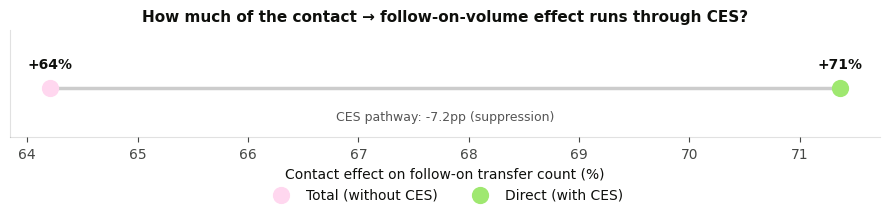

CES carries a REAL, non-trivial pathway here (unlike evidence friction): contact
strongly lowers CES (-0.66pt) and CES strongly lifts volume (+7.5%/pt), so the
indirect path is ~-7pp. But it runs OPPOSITE to the total effect -> SUPPRESSION,
not weak mediation. Adding CES raises the contact coefficient (64% -> 71%) because
it nets out the negative experience channel, exposing a larger intent-driven effect.
Takeaway: the headline +contact->+volume is intent; the experience channel that
CES captures actually pulls the other way.


In [30]:
# --- Dumbbell: contact's effect on follow-on volume, with vs without CES -------
# Visualises the mediation above. The GAP between dots = the part of contact's effect
# that runs through CES. Here the dots sit on OPPOSITE sides: total (no CES) is lower
# than direct (with CES), because the CES pathway works AGAINST the dominant effect.
fig, ax = plt.subplots(figsize=(9, 2.6))

ax.hlines(0, total, direct, color='#cccccc', lw=2.5, zorder=1)             # mediation gap
ax.scatter(total,  0, s=130, color=wise_colours.BRIGHT_PINK,  zorder=2, label='Total (without CES)')
ax.scatter(direct, 0, s=130, color=wise_colours.BRIGHT_GREEN, zorder=3, label='Direct (with CES)')

ax.annotate(f"{total:+.0f}%",  (total, 0),  ha='center', va='bottom', xytext=(0, 12),
            textcoords='offset points', fontsize=10, fontweight='bold')
ax.annotate(f"{direct:+.0f}%", (direct, 0), ha='center', va='bottom', xytext=(0, 12),
            textcoords='offset points', fontsize=10, fontweight='bold')
ax.annotate(f"CES pathway: {mediated:+.1f}pp (suppression)",
            ((total + direct) / 2, 0), ha='center', va='top', xytext=(0, -16),
            textcoords='offset points', fontsize=9, color='#555')

ax.set_yticks([])
ax.set_ylim(-0.5, 0.6)
ax.set_xlabel('Contact effect on follow-on transfer count (%)')
ax.set_title('How much of the contact → follow-on-volume effect runs through CES?', fontsize=11)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

print("CES carries a REAL, non-trivial pathway here (unlike evidence friction): contact")
print("strongly lowers CES (-0.66pt) and CES strongly lifts volume (+7.5%/pt), so the")
print("indirect path is ~-7pp. But it runs OPPOSITE to the total effect -> SUPPRESSION,")
print("not weak mediation. Adding CES raises the contact coefficient (64% -> 71%) because")
print("it nets out the negative experience channel, exposing a larger intent-driven effect.")
print("Takeaway: the headline +contact->+volume is intent; the experience channel that")
print("CES captures actually pulls the other way.")

**Note on the CES model fit.** Contact (plus controls) explains only ~3% of CES variance (R²=0.029). This does *not* weaken the mediation finding — contact reliably *shifts* CES (−0.66 points, p<0.001); it's just a small *component* of an individual's overall score, which is dominated by everything else in the experience (fees, speed, trust, disposition). The same ~3% appears in the evidence analysis, and reinforces the programme thesis: any single operational driver is a minor ingredient of a global effort score, so detecting and acting on a *specific* driver calls for a targeted measure rather than the blunt aggregate.